<a href="https://colab.research.google.com/github/Igorbraziel/deep-learning-with-pytorch/blob/main/02_neural_network_classification/02_neural_network_classification_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Classification with PyTorch

In [1]:
import sklearn
from sklearn.datasets import make_circles

In [2]:
X, y = make_circles(n_samples=1000, noise=0.03, random_state=77)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
X[:10], y[:10]

(array([[-0.39987727,  0.9250332 ],
        [ 0.16235459,  0.95396597],
        [-0.81230383,  0.62151465],
        [ 0.78083028, -0.28709668],
        [-0.60755452, -0.80481205],
        [ 0.88540619,  0.46937766],
        [ 0.79385033, -0.66214144],
        [ 0.37173704,  0.72193086],
        [ 0.90607587, -0.43831361],
        [-0.91857827,  0.32647221]]),
 array([0, 0, 0, 1, 0, 0, 0, 1, 0, 0]))

In [5]:
import pandas as pd

In [6]:
circles_df = pd.DataFrame({
    "X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})

circles_df.head()

,X1,X2,label
0,-0.399877,0.925033,0
1,0.162355,0.953966,0
2,-0.812304,0.621515,0
3,0.780830,-0.287097,1
4,-0.607555,-0.804812,0


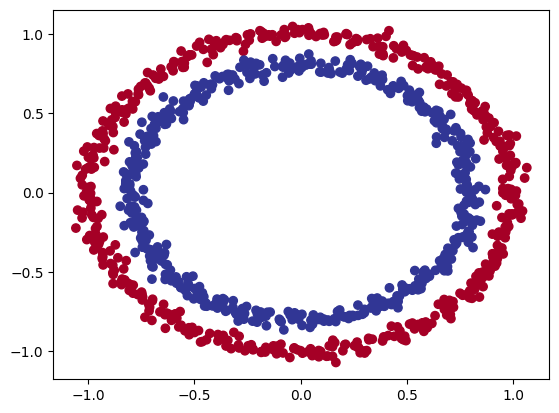

In [7]:
# Visuzalize
import matplotlib.pyplot as plt

plt.scatter(x=circles_df["X1"], y=circles_df["X2"], c=circles_df["label"], cmap=plt.cm.RdYlBu)

## Turn our data into tensors

In [8]:
import torch

In [9]:
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## Buuilding a Model

In [12]:
from torch import nn

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [14]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_2(self.layer_1(x))

In [15]:
circle_model = CircleModelV0().to(device)
circle_model.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.0570, -0.0405],
                      [-0.2329,  0.0633],
                      [ 0.0409,  0.3165],
                      [-0.6376,  0.3516],
                      [ 0.5232,  0.0998]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3435,  0.0076, -0.0433, -0.1737, -0.3468], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.0413, -0.4213,  0.1022, -0.2978, -0.1141]], device='cuda:0')),
             ('layer_2.bias', tensor([0.2468], device='cuda:0'))])

In [16]:
# Replicating the model using nn.Sequential()

In [17]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [18]:
# Make predictions with the model
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print("Test labels:", y_test[:10])
print("Rounded Predictions:", torch.round(untrained_preds[:10].squeeze(dim=1)))

Test labels: tensor([1., 1., 0., 1., 0., 0., 0., 1., 0., 0.])
Rounded Predictions: tensor([-0., -0., 0., -0., 0., -0., -0., -0., -0., -0.], device='cuda:0')


## Setting up a loss function, optimizer and evaluation functions

In [19]:
"""
For our problem (binary classification) the adequate loss function is
the Binary cross entropy loss. nn.BCEWithLogitsLoss()
"""
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [20]:
# Our accuracy function
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  accuracy = (correct / len(y_pred)) * 100
  return accuracy

## Training our model

In [21]:
# raw logits -> prediction probabilities -> prediction labels
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))

y_pred_probs = torch.sigmoid(y_logits)

y_labels = torch.round(y_pred_probs)
y_labels[:5], y_pred_probs[:5]

(tensor([[0.],
         [0.],
         [1.],
         [0.],
         [1.]], device='cuda:0'),
 tensor([[0.4206],
         [0.4806],
         [0.5061],
         [0.4260],
         [0.5285]], device='cuda:0'))

In [22]:
accuracy_fn(y_test.to(device), y_labels.squeeze())

45.0

In [23]:
# Training loop
torch.manual_seed(42) if device != "cuda" else torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

def training_loop(model: torch.nn.Module, optimizer, loss_fn, epochs = 1000):
  for epoch in range(epochs):
    model.train()
    # 1. Forward pass
    y_logits = model(X_train).squeeze()
    y_pred_probs = torch.sigmoid(y_logits)
    y_pred = torch.round(y_pred_probs)

    # 2. Calculate the loss / accuracy
    loss = loss_fn(y_logits, y_train) # Expects raw logits as input
    accuracy = accuracy_fn(y_train, y_pred)

    # 3. Optimizer Zero grad
    optimizer.zero_grad()

    # 4. Backpropagation (loss backward)
    loss.backward()

    # 5. Gradient Descent
    optimizer.step()

    # Testing
    model.eval()
    with torch.inference_mode():
      test_logits = model(X_test).squeeze()
      test_pred_probs = torch.sigmoid(test_logits)
      test_pred = torch.round(test_pred_probs)

      # Test loss / accuracy
      test_loss = loss_fn(test_logits, y_test)
      test_accuracy = accuracy_fn(y_test, test_pred)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Test Loss: {test_loss:.5f} | Test Accuracy: {test_accuracy:.2f} | Train Loss: {loss:.5f} | Train Accuracy: {accuracy:.2f}")

In [24]:
training_loop(model_0, optimizer, loss_fn, 1000)

Epoch: 0 | Test Loss: 0.70375 | Test Accuracy: 45.00 | Train Loss: 0.69731 | Train Accuracy: 48.38
Epoch: 100 | Test Loss: 0.70260 | Test Accuracy: 43.50 | Train Loss: 0.69502 | Train Accuracy: 50.62
Epoch: 200 | Test Loss: 0.70199 | Test Accuracy: 44.50 | Train Loss: 0.69418 | Train Accuracy: 50.88
Epoch: 300 | Test Loss: 0.70139 | Test Accuracy: 45.50 | Train Loss: 0.69377 | Train Accuracy: 51.12
Epoch: 400 | Test Loss: 0.70078 | Test Accuracy: 46.00 | Train Loss: 0.69352 | Train Accuracy: 50.88
Epoch: 500 | Test Loss: 0.70020 | Test Accuracy: 48.00 | Train Loss: 0.69334 | Train Accuracy: 51.00
Epoch: 600 | Test Loss: 0.69967 | Test Accuracy: 49.00 | Train Loss: 0.69321 | Train Accuracy: 50.62
Epoch: 700 | Test Loss: 0.69921 | Test Accuracy: 48.50 | Train Loss: 0.69311 | Train Accuracy: 50.50
Epoch: 800 | Test Loss: 0.69880 | Test Accuracy: 48.50 | Train Loss: 0.69304 | Train Accuracy: 51.00
Epoch: 900 | Test Loss: 0.69845 | Test Accuracy: 49.00 | Train Loss: 0.69299 | Train Accuracy

## Making predictions and evaluating the model

In [25]:
# getting some helper functions
import requests
from pathlib import Path

hf_path = Path("helper_functions.py")

if hf_path.is_file():
  print(f"{hf_path} already exists")
else:
  try:
    response = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")

    with open(hf_path, "wb") as f:
      f.write(response.content)
  except requests.exceptions.RequestException as e:
    print(f"Error while making the request: {e}")

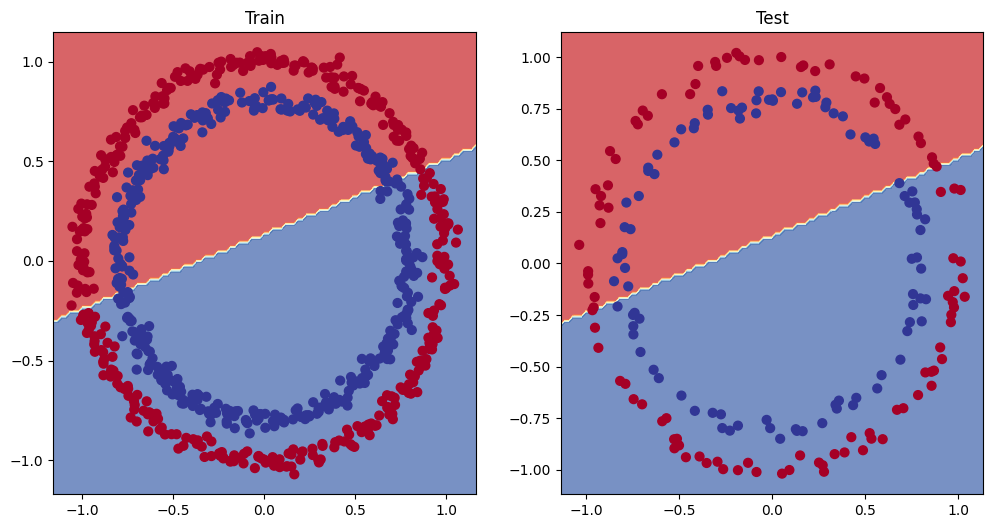

In [26]:
# Plot decision boundary of the model
from helper_functions import plot_decision_boundary

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)


## Improving our model

In [27]:
# Changing our activation function (non-linearity), Adding layers and also hidden units
model_1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=32),
    nn.ReLU(),
    nn.Linear(in_features=32, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=1),
).to(device)

In [28]:
loss_fn = nn.BCEWithLogitsLoss()
# Changing the optimizer and the learning rate
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.0001)


In [29]:
torch.manual_seed(42) if device != "cuda" else torch.cuda.manual_seed(42)

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Training for a longer
training_loop(model_1, optimizer, loss_fn, 1500)

Epoch: 0 | Test Loss: 0.69714 | Test Accuracy: 48.00 | Train Loss: 0.69379 | Train Accuracy: 50.50
Epoch: 100 | Test Loss: 0.68716 | Test Accuracy: 56.00 | Train Loss: 0.68388 | Train Accuracy: 59.13
Epoch: 200 | Test Loss: 0.66496 | Test Accuracy: 79.50 | Train Loss: 0.66025 | Train Accuracy: 82.75
Epoch: 300 | Test Loss: 0.59797 | Test Accuracy: 89.50 | Train Loss: 0.59152 | Train Accuracy: 91.75
Epoch: 400 | Test Loss: 0.46990 | Test Accuracy: 95.50 | Train Loss: 0.46039 | Train Accuracy: 97.88
Epoch: 500 | Test Loss: 0.31489 | Test Accuracy: 99.50 | Train Loss: 0.30127 | Train Accuracy: 99.25
Epoch: 600 | Test Loss: 0.19605 | Test Accuracy: 99.50 | Train Loss: 0.18226 | Train Accuracy: 100.00
Epoch: 700 | Test Loss: 0.12329 | Test Accuracy: 100.00 | Train Loss: 0.11222 | Train Accuracy: 100.00
Epoch: 800 | Test Loss: 0.08168 | Test Accuracy: 100.00 | Train Loss: 0.07278 | Train Accuracy: 100.00
Epoch: 900 | Test Loss: 0.05763 | Test Accuracy: 100.00 | Train Loss: 0.05016 | Train Ac

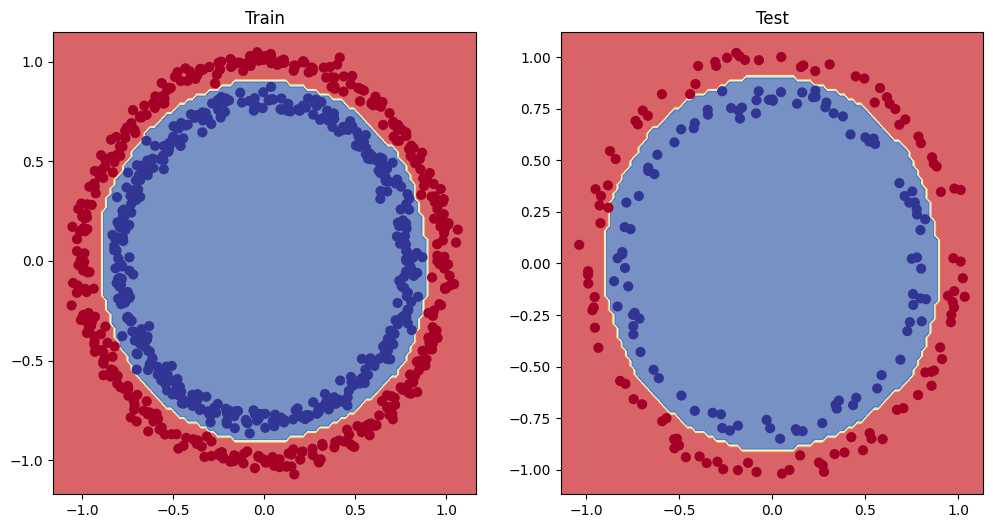

In [30]:
# Evaluating our model again

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

## Multi-Class Classification

In [31]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [32]:
class HyperparametersConfig:
  NUM_CLASSES = 4
  NUM_FEATURES = 2
  RANDOM_SEED = 42
  device = "cuda" if torch.cuda.is_available() else "cpu"

class TensorOperations:
  @staticmethod
  def from_numpy_to_tensor(x: np.ndarray) -> torch.Tensor:
    return torch.from_numpy(x).type(torch.float).to(HyperparametersConfig.device)

  @staticmethod
  def tensor_to_cpu(x: torch.Tensor) -> np.ndarray:
    return x.detach().cpu()

  @staticmethod
  def accuracy_fn(y_true, y_preds):
    correct = torch.eq(y_true, y_preds).sum().item()
    acc = (correct / len(y_preds)) * 100
    return acc

class TensorData:
  def __init__(self, X: torch.Tensor, y: torch.Tensor):
    self.X_blob_tensor, self.y_blob_tensor = X, y
    split_data = train_test_split(X, y, test_size=0.2, random_state=HyperparametersConfig.RANDOM_SEED)
    self.X_blob_train, self.X_blob_test, self.y_blob_train, self.y_blob_test = [x.to(HyperparametersConfig.device) for x in split_data]

class PlotUtils:
  @staticmethod
  def config():
    plt.figure(figsize=(10, 7))

  @staticmethod
  def scatter_blobs(X_blob: torch.Tensor, y_blob: torch.Tensor):
    plt.scatter(X_blob[:, 0].cpu(), X_blob[:, 1].cpu(), c=y_blob.cpu(), cmap=plt.cm.RdYlBu)

  @staticmethod
  def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    cpu_device = torch.device("cpu")
    model = model.to(cpu_device)
    X, y = X.to(cpu_device), y.to(cpu_device)

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().cpu().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

  @classmethod
  def decision_boundary_plot(cls, model: nn.Module, X_train, X_test, y_train, y_test):
    plt.figure(figsize=(10, 7))

    plt.subplot(1, 2, 1)
    plt.title("Train")
    cls.plot_decision_boundary(model, X_train, y_train)

    plt.subplot(1, 2, 2)
    plt.title("Test")
    cls.plot_decision_boundary(model, X_test, y_test)

In [33]:
# Creating some data samples

X_blob, y_blob = make_blobs(
    n_samples=1000,
    n_features=HyperparametersConfig.NUM_FEATURES,
    centers=HyperparametersConfig.NUM_CLASSES,
    cluster_std=1.5,
    random_state=HyperparametersConfig.RANDOM_SEED
)

X_blob_tensor = TensorOperations.from_numpy_to_tensor(X_blob)
y_blob_tensor = TensorOperations.from_numpy_to_tensor(y_blob)

print(X_blob_tensor.shape, y_blob_tensor.shape)
print(X_blob_tensor[:10], y_blob_tensor[:10])

tensor_data = TensorData(X_blob_tensor, y_blob_tensor)

torch.Size([1000, 2]) torch.Size([1000])
tensor([[-8.4134,  6.9352],
        [-5.7665, -6.4312],
        [-6.0421, -6.7661],
        [ 3.9508,  0.6984],
        [ 4.2505, -0.2815],
        [-6.7941, -6.4772],
        [ 5.2102,  2.8890],
        [-5.5051, -6.3604],
        [-6.5438, -4.8339],
        [ 6.4496,  0.7478]], device='cuda:0') tensor([3., 2., 2., 1., 1., 2., 1., 2., 2., 1.], device='cuda:0')


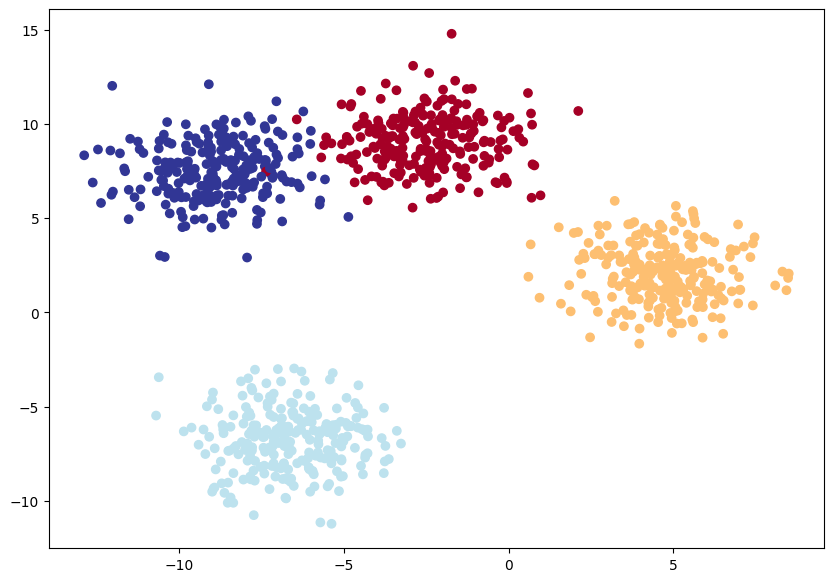

In [34]:
# Visualizing our data
PlotUtils.config()
PlotUtils.scatter_blobs(X_blob_tensor, y_blob_tensor)

## Building Our Model

In [35]:
from torch import nn

In [36]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, device, random_seed, hidden_units):
    super().__init__()

    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)

    self.layers_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

    self.to(device)

  def create_loss_fn_and_optim(self):
    self.loss_fn = nn.CrossEntropyLoss()
    self.optimizer = torch.optim.Adam(self.parameters(), lr=0.001)

  def get_predictions_labels(self, x: torch.Tensor) -> torch.Tensor:
    self.eval()
    with torch.inference_mode():
      y_logits = self.forward(x)
      y_probs = torch.softmax(y_logits, dim=1)
      y_preds = torch.argmax(y_probs, dim=1)
    return y_preds

  def train_blob_model(self, epochs, X_train, X_test, y_train, y_test):
    for epoch in range(epochs):
      self.train()

      # Forward pass
      y_logits = self.forward(X_train)
      y_probs = torch.softmax(y_logits, dim=1)
      y_preds = torch.argmax(y_probs, dim=1)

      # Calculate the loss / accuracy
      loss = self.loss_fn(y_logits, y_train)
      acc = TensorOperations.accuracy_fn(y_train, y_preds)

      # Zero Grad
      self.optimizer.zero_grad()

      # Backward (backpropagation)
      loss.backward()

      # Optimizer step
      self.optimizer.step()

      self.eval()
      with torch.inference_mode():
        test_logits = self.forward(X_test)
        test_probs = torch.softmax(test_logits, dim=1)
        test_preds = torch.argmax(test_probs, dim=1)

        test_loss = self.loss_fn(test_logits, y_test)
        test_acc = TensorOperations.accuracy_fn(y_test, test_preds)

      if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train acc: {acc:.5f} | Test Loss: {test_loss:.5f} | Test acc: {test_acc:.5f}")

  def forward(self, x: torch.Tensor):
    return self.layers_stack(x).to(device)

In [37]:
# Instantiating a model

blob_model = BlobModel(
  input_features=HyperparametersConfig.NUM_FEATURES,
  output_features=HyperparametersConfig.NUM_CLASSES,
  device=HyperparametersConfig.device,
  random_seed=HyperparametersConfig.RANDOM_SEED,
  hidden_units=32
)

# Creating the loss function and optimizer
blob_model.create_loss_fn_and_optim()

y_preds = blob_model.get_predictions_labels(tensor_data.X_blob_tensor)
print(y_preds[:10])

tensor([2, 0, 0, 1, 2, 0, 1, 0, 0, 1], device='cuda:0')


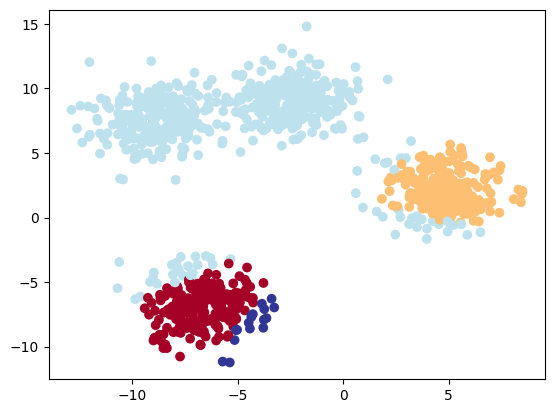

In [38]:
PlotUtils.scatter_blobs(tensor_data.X_blob_tensor, y_preds)

In [39]:
# Training the model
blob_model.train_blob_model(
  epochs=1000,
  X_train=tensor_data.X_blob_train,
  X_test=tensor_data.X_blob_test,
  y_train=tensor_data.y_blob_train.long(),
  y_test=tensor_data.y_blob_test.long()
)

Epoch: 0 | Train Loss: 1.52792 | Train acc: 25.12500 | Test Loss: 1.45465 | Test acc: 24.00000
Epoch: 100 | Train Loss: 0.03609 | Train acc: 99.25000 | Test Loss: 0.02771 | Test acc: 99.50000
Epoch: 200 | Train Loss: 0.02498 | Train acc: 99.37500 | Test Loss: 0.01551 | Test acc: 99.50000
Epoch: 300 | Train Loss: 0.02236 | Train acc: 99.37500 | Test Loss: 0.01212 | Test acc: 99.50000
Epoch: 400 | Train Loss: 0.02102 | Train acc: 99.37500 | Test Loss: 0.01042 | Test acc: 99.50000
Epoch: 500 | Train Loss: 0.01998 | Train acc: 99.50000 | Test Loss: 0.00911 | Test acc: 99.50000
Epoch: 600 | Train Loss: 0.01906 | Train acc: 99.50000 | Test Loss: 0.00806 | Test acc: 99.50000
Epoch: 700 | Train Loss: 0.01821 | Train acc: 99.50000 | Test Loss: 0.00717 | Test acc: 100.00000
Epoch: 800 | Train Loss: 0.01742 | Train acc: 99.50000 | Test Loss: 0.00630 | Test acc: 100.00000
Epoch: 900 | Train Loss: 0.01647 | Train acc: 99.50000 | Test Loss: 0.00543 | Test acc: 100.00000


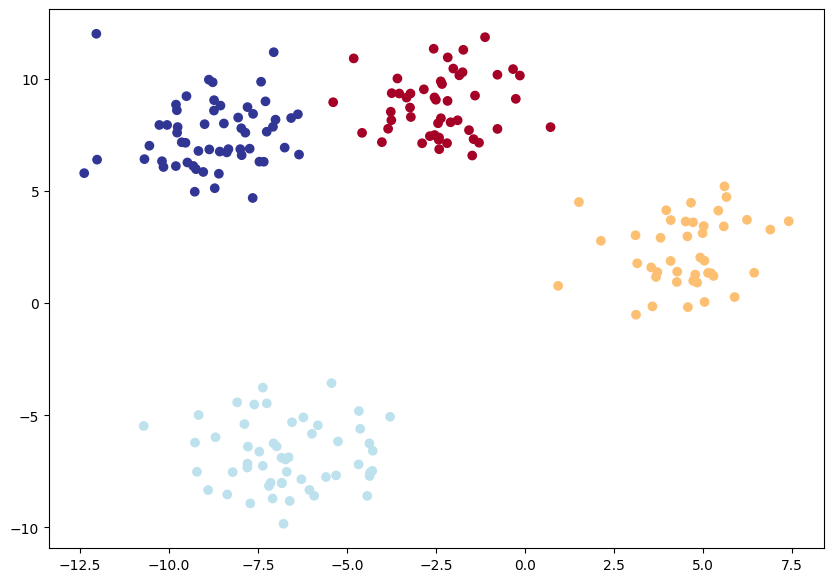

In [40]:
# Evaluating our model
y_preds = blob_model.get_predictions_labels(tensor_data.X_blob_test)
PlotUtils.config()
PlotUtils.scatter_blobs(tensor_data.X_blob_test, y_preds)

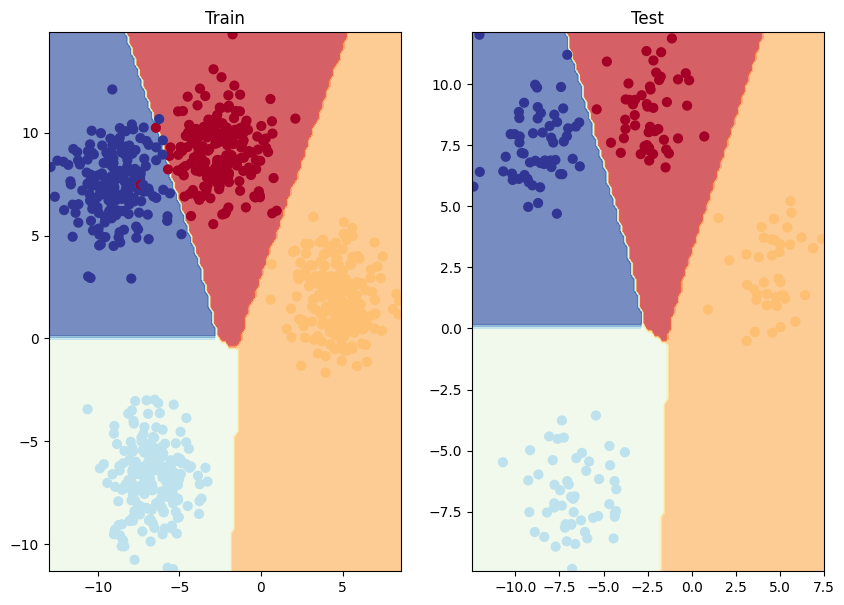

In [41]:
PlotUtils.decision_boundary_plot(
    blob_model.to("cpu"),
    tensor_data.X_blob_train,
    tensor_data.X_blob_test,
    tensor_data.y_blob_train,
    tensor_data.y_blob_test,
)

## Classification Metrics

In [43]:
%pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 61.6 MB/s eta 0:00:00


In [47]:
import torchmetrics

In [53]:
# Accuracy

torchmetrics_acc = torchmetrics.Accuracy(task="multiclass", num_classes=HyperparametersConfig.NUM_CLASSES).to(HyperparametersConfig.device)

accuracy = torchmetrics_acc(y_preds, tensor_data.y_blob_test)
print(accuracy.item())

1.0
